#Import Libraries

In [1]:
# Standard library
import os
import math

# Third-party libraries
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import transforms

import random

from google.colab import userdata

# -----------------------------
# Device configuration
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [3]:
def send_to_gpu(*vars):
    if not torch.cuda.is_available():
        raise Exception("CUDA not available")
    
    device = torch.device("cuda")
    moved = []
    
    for v in vars:
        if isinstance(v, nn.Module):
            if torch.cuda.device_count() > 1:
                v = nn.DataParallel(v)
            v = v.to(device)
        else:
            v = v.to(device)
        moved.append(v)
    
    return moved[0] if len(moved) == 1 else moved

# Load Data

In [4]:
# from google.colab import userdata

# os.environ['KAGGLE_USERNAME'] = userdata.get('username')
# os.environ['KAGGLE_KEY'] = userdata.get('key')
# os.environ['RAY_PICKLE_VERBOSE_DEBUG'] = '1'

# !kaggle competitions download -c ecse-551-assignment-2-image-classification > /dev/null 2>&1
# !unzip ecse-551-assignment-2-image-classification.zip > /dev/null 2>&1

# !rm ecse-551-assignment-2-image-classification.zip

# print("Downloaded and extracted dataset.")

## ImageDataset

In [5]:
class ImageDataset(Dataset):
    def __init__(self, df, img_dir,
                 transform=None,
                 ):
        """
        labels: pandas DataFrame with ['id', 'label']
        img_dir: path to image directory
        target_size: resize target (H, W) --> Standard is 32x32
        normalize_range: "0-1", "-1-1", or None
        """
        self.labels = df['label'].astype(str)

        # reset indices accordingly.
        self.df = df.reset_index(drop=True)

        self.img_dir = img_dir

        self.transform = transform

        # indexing with unique image names
        self.classes = sorted(self.labels.unique().tolist())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx, 0]  # filename
        label = self.df.iloc[idx, 1]     # class name

        # img_path = os.path.join(self.img_dir, img_name)
        img_path = os.path.abspath(os.path.join(self.img_dir, img_name))
        image = Image.open(img_path).convert('RGB')
        # Applying our sequence of transformations defined prev before returning the image (pseudo func prog)
        if self.transform:
          image = self.transform(image)

        label_idx = self.class_to_idx[label]

        return image, label_idx

## Preprocessing

In [6]:
img_dir='/kaggle/input/ecse-551-assignment-2-image-classification/kaggle_challenge/train'
labels_csv_file='/kaggle/input/ecse-551-assignment-2-image-classification/kaggle_challenge/train_labels.csv'
labels_df = pd.read_csv(labels_csv_file)

train_transform = transforms.Compose([
    transforms.Resize(160),
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Resize(128),  # Resize to 128x128 for validation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = ImageDataset(labels_df, img_dir)

In [7]:
def preprocess(train_subset, val_subset, batch_size):
    train_dataset = ImageDataset(train_subset, img_dir=img_dir, transform=train_transform)
    val_dataset   = ImageDataset(val_subset,   img_dir=img_dir, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=2, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, num_workers=2, shuffle=False)

    return train_loader, val_loader

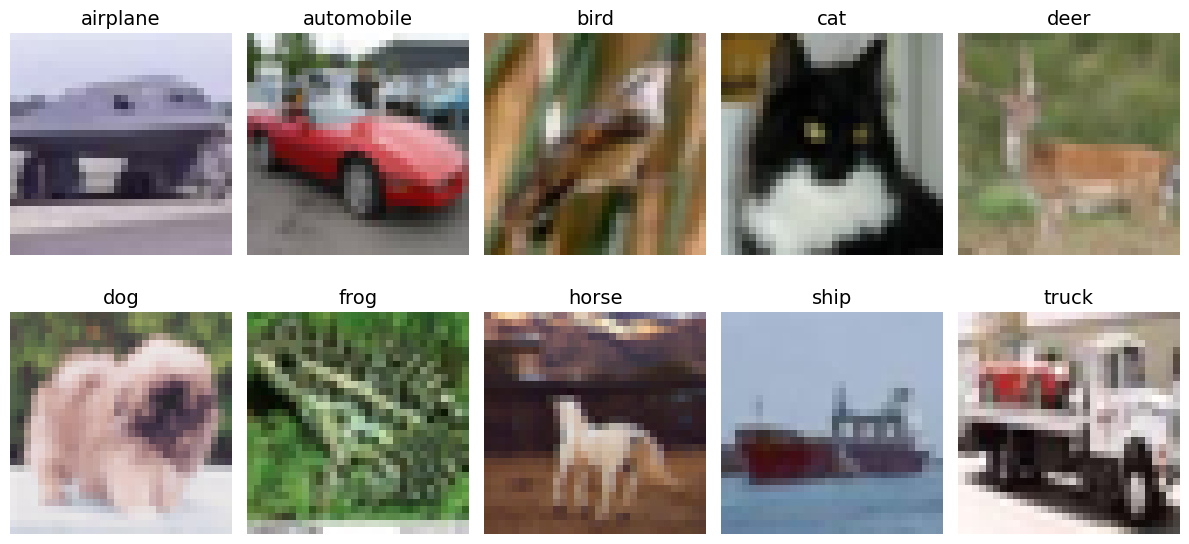

In [10]:
import matplotlib.pyplot as plt

# Get one sample per class
sample_images = []
for cls in dataset.classes:
    # find first index of this class
    idx = dataset.df[dataset.df['label'] == cls].index[0]
    img, label_idx = dataset[idx]
    sample_images.append((img, cls))

# Plot in 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for ax, (img, cls) in zip(axes, sample_images):
    # If transform returns tensor, convert back to numpy for plotting
    if hasattr(img, 'permute'):  # torch.Tensor
        img_np = img.permute(1, 2, 0).numpy()
    else:
        img_np = img
    ax.imshow(img_np)
    ax.set_title(cls, fontsize=14)  # <-- increase font size here
    ax.axis('off')

# Hide unused axes if fewer than 10 classes
for ax in axes[len(sample_images):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Vision Transformer

## PatchEmbedding

In [9]:
class PatchEmbedding(nn.Module):
  def __init__(self, img_size, patch_size, in_channels, embed_dim):
    super().__init__()
    self.patch_size = patch_size
    self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
    num_patches = (img_size // patch_size) ** 2
    self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
    self.pos_embed = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))
      
    # Init the patch kernel
    fan_in = self.proj.in_channels * self.proj.kernel_size[0] * self.proj.kernel_size[1]
    nn.init.trunc_normal_(self.proj.weight, std=math.sqrt(1 / fan_in))
    nn.init.zeros_(self.proj.bias)

  def forward(self, x):
    B = x.size(0)
    x = self.proj(x)  # (B, embed dimension, H/p, W/p)
    x = x.flatten(2).transpose(1, 2)  # (B, N_patches, d)
    cls_tokens = self.cls_token.expand(B, -1, -1)
    x = torch.cat((cls_tokens, x), dim=1)
    x = x + self.pos_embed
    return x

In [10]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, drop_rate = 0.0):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.dropout = nn.Dropout(drop_rate)

    def forward(self, x):
        x = self.dropout(F.gelu(self.fc1(x)))
        x = self.dropout(self.fc2(x))
        return x

## EncoderLayer

In [11]:
from timm.layers import DropPath

class EncoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim,
                 drop_rate=0.0, drop_path=0.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=drop_rate, batch_first=True)

        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_dim, drop_rate)

    def forward(self, x):
        # Attention block
        x_norm = self.norm1(x)
        attn_out = self.attention(x_norm, x_norm, x_norm, need_weights=False)[0]
        x = x + self.drop_path(attn_out)

        # MLP block
        mlp_out = self.mlp(self.norm2(x))
        x = x + self.drop_path(mlp_out)

        return x

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

## ViT

In [12]:
class ViT(nn.Module):
    def __init__(
      self,
      image_size: int,
      patch_size: int,
      in_channels: int,
      depth: int,
      num_heads: int,
      embed_dim: int,
      mlp_dim: int,
      drop_rate: float = 0.0,
      drop_path: float = 0.0,
      num_classes: int = 10,
    ):
      super().__init__()
      self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)
      self.encoder = nn.Sequential(*[
          EncoderLayer(embed_dim, num_heads, mlp_dim, drop_rate, drop_path)
          for _ in range(depth)
      ])
      self.norm = nn.LayerNorm(embed_dim)
      self.head = nn.Linear(embed_dim, num_classes)

      nn.init.zeros_(self.head.weight)
      nn.init.zeros_(self.head.bias)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.encoder(x)
        x = self.norm(x)
        cls_token = x[:, 0]
        return self.head(cls_token)

# ViT Training & Validation Setup

## LR Scheduler

In [13]:
from torch.optim.lr_scheduler import LambdaLR

def get_warmup_cosine_scheduler(optimizer, warmup_steps, total_steps, min_lr=1e-6):
    def lr_lambda(step):
        # 1. Linear warmup
        if step < warmup_steps:
            return step / warmup_steps

        # 2. Cosine decay
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))

        # Ensures LR never goes below min_lr
        return max(cosine_decay, min_lr / optimizer.defaults['lr'])

    return LambdaLR(optimizer, lr_lambda)

## Training Function

In [15]:
def train(model, loader, optimizer, loss_fn, scheduler):
    model.train()
    total_loss, correct = 0, 0
    for x, y in loader:
        x, y = send_to_gpu(x, y)
        optimizer.zero_grad()
        
        outputs = model(x)
        loss = loss_fn(outputs, y)

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * x.size(0)
        correct += (outputs.argmax(1) == y).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)

## Validate Function

In [16]:
def validate(model, loader, loss_fn):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = send_to_gpu(x, y)
            out = model(x)
            loss = loss_fn(out, y)

            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

# ViT Hyper-parameter Optimization

## Model Configurations

In [17]:
# Constant hyperparameters
IMAGE_SIZE= 128
PATCH_SIZE = 16
CHANNELS = 3
NUM_CLASSES = 10
N_SPLITS = 5
LR = 3e-4
BATCH_SIZE = 128
EPOCHS = 3
DROP_RATE = 0.1
WEIGHT_DECAY = 0.1

# Variable hyperparameters for HPO
configs = [
    {
        "EMBED_DIM": 256,
        "NUM_HEADS": 8,
        "DEPTH": 6,
        "MLP_DIM": 512,
    },
    {
        "EMBED_DIM": 192,
        "NUM_HEADS": 3,
        "DEPTH": 12,
        "MLP_DIM": 768,
    }, # ViT-Ti
    {
        "EMBED_DIM": 384,
        "NUM_HEADS": 6,
        "DEPTH": 12,
        "MLP_DIM": 1536,
    }, #ViT-S
]

## Stratified 5 Fold Validation

In [72]:
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

results = []
all_fold_metrics = []

for cfg_idx, cfg in enumerate(configs, 1):
    fold_scores, fold_losses = [], []

    print(f"\n=== Evaluating Config {cfg_idx}/{len(configs)} ===")
    print(cfg)

    # regenerate the splits for each config
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(labels_df, labels_df["label"]), 1):
        train_subset = labels_df.iloc[train_idx]
        val_subset   = labels_df.iloc[val_idx]

        train_loader, val_loader = preprocess(
            train_subset, val_subset, BATCH_SIZE
        )

        model = ViT(
            image_size=IMAGE_SIZE,
            patch_size=PATCH_SIZE,
            in_channels=CHANNELS,
            num_classes=NUM_CLASSES,
            depth=cfg["DEPTH"],
            num_heads=cfg["NUM_HEADS"],
            embed_dim=cfg["EMBED_DIM"],
            mlp_dim=cfg["MLP_DIM"],
            drop_rate=DROP_RATE,
            drop_path=DROP_RATE
        )
        model = send_to_gpu(model)

        optimizer = optim.AdamW(
            model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
        )
        loss_fn = nn.CrossEntropyLoss()

        total_steps = EPOCHS * len(train_loader)
        warmup_steps = int(0.05 * total_steps)
        scheduler = get_warmup_cosine_scheduler(
            optimizer, warmup_steps, total_steps, min_lr=1e-6
        )

        for epoch in range(EPOCHS):
            train_loss, train_acc = train(model, train_loader, optimizer, loss_fn, scheduler)
            val_loss, val_acc = validate(model, val_loader, loss_fn)
            print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss}, Train Acc: {train_acc}, Validation Acc: {val_acc}")
        
        fold_scores.append(val_acc)
        fold_losses.append(val_loss)

        print(f"Config {cfg_idx}, Fold {fold_idx} | Val Acc: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

    avg_acc = np.mean(fold_scores)
    avg_loss = np.mean(fold_losses)

    print(f"Config {cfg_idx} | Avg Val Acc: {avg_acc:.4f}, Avg Val Loss: {avg_loss:.4f}")

    results.append((cfg, avg_acc))
    all_fold_metrics.append({
        "config": cfg,
        "fold_accuracies": fold_scores,
        "fold_losses": fold_losses,
        "avg_accuracy": avg_acc,
        "avg_loss": avg_loss
    })


=== Evaluating Config 1/3 ===
{'EMBED_DIM': 256, 'NUM_HEADS': 8, 'DEPTH': 6, 'MLP_DIM': 512}
Epoch 1/3, Train Loss: 2.1198142585754396, Train Acc: 0.19725, Validation Acc: 0.246
Epoch 2/3, Train Loss: 1.9418781204223632, Train Acc: 0.27, Validation Acc: 0.2965
Epoch 3/3, Train Loss: 1.8781697406768798, Train Acc: 0.30225, Validation Acc: 0.3155
Config 1, Fold 1 | Val Acc: 0.3155, Val Loss: 1.8704
Epoch 1/3, Train Loss: 2.134091139793396, Train Acc: 0.18125, Validation Acc: 0.267
Epoch 2/3, Train Loss: 1.95350790309906, Train Acc: 0.2675, Validation Acc: 0.308
Epoch 3/3, Train Loss: 1.8821605892181397, Train Acc: 0.30175, Validation Acc: 0.334
Config 1, Fold 2 | Val Acc: 0.3340, Val Loss: 1.8476
Epoch 1/3, Train Loss: 2.1145762596130373, Train Acc: 0.203375, Validation Acc: 0.2505
Epoch 2/3, Train Loss: 1.9305222845077514, Train Acc: 0.273875, Validation Acc: 0.2885
Epoch 3/3, Train Loss: 1.8786576957702636, Train Acc: 0.297375, Validation Acc: 0.3235
Config 1, Fold 3 | Val Acc: 0.3235

In [73]:
# Select best configuration
scores = [score for (_, score) in results]
best_index = int(np.argmax(scores))
best_cfg, best_score = results[best_index]

print("=== Best Hyperparameters ===")
print(best_cfg)
print(f"Best Cross-Validation Accuracy: {best_score:.4f}")

# Extract metrics for the best configuration only
best_cfg_metrics = next(cfg_data for cfg_data in all_fold_metrics if cfg_data["config"] == best_cfg)

# Training/validation losses and accuracies
best_fold_accuracies = best_cfg_metrics["fold_accuracies"]
best_fold_losses = best_cfg_metrics["fold_losses"]

=== Best Hyperparameters ===
{'EMBED_DIM': 256, 'NUM_HEADS': 8, 'DEPTH': 6, 'MLP_DIM': 512}
Best Cross-Validation Accuracy: 0.3218


# Best ViT Model Training

In [18]:
# Training of best model
best_cfg = {'EMBED_DIM': 256, 'NUM_HEADS': 8, 'DEPTH': 6, 'MLP_DIM': 512}
EPOCHS = 50 
model = ViT(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=CHANNELS,
    num_classes=NUM_CLASSES,
    depth=best_cfg["DEPTH"],
    num_heads=best_cfg["NUM_HEADS"],
    embed_dim=best_cfg["EMBED_DIM"],
    mlp_dim=best_cfg["MLP_DIM"],
    drop_rate=DROP_RATE,
    drop_path=DROP_RATE
)
model = send_to_gpu(model)

In [19]:
from sklearn.model_selection import train_test_split

train_indices, test_indices = train_test_split(
    range(len(dataset)),
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=labels_df["label"]
)

train_subset = labels_df.iloc[train_indices]
test_subset   = labels_df.iloc[test_indices]

train_loader, test_loader = preprocess(train_subset, test_subset, BATCH_SIZE)

In [20]:
total_steps = EPOCHS * len(train_loader)
warmup_steps = int(0.05 * total_steps)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = get_warmup_cosine_scheduler(optimizer, warmup_steps, total_steps, min_lr=1e-6)

metrics_df = pd.DataFrame(columns=["epoch", "train_loss", "train_acc", "test_loss", "test_acc"])

In [21]:
for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, loss_fn, scheduler)
    test_loss, test_acc = validate(model, test_loader, loss_fn)

    metrics_df.loc[epoch] = [epoch+1, train_loss, train_acc, test_loss, test_acc]
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss}, Train Acc: {train_acc}, Test Loss: {test_loss}, Test Acc: {test_acc}")

metrics_df.to_csv("training_metrics.csv", index=False)

Epoch 1/50, Train Loss: 2.252733890533447, Train Acc: 0.1605, Test Loss: 2.1262577476501465, Test Acc: 0.1885
Epoch 2/50, Train Loss: 2.0533180332183836, Train Acc: 0.220875, Test Loss: 1.951675033569336, Test Acc: 0.2675
Epoch 3/50, Train Loss: 1.922416202545166, Train Acc: 0.2765, Test Loss: 1.8428976593017579, Test Acc: 0.3045
Epoch 4/50, Train Loss: 1.8279421052932738, Train Acc: 0.320125, Test Loss: 1.740185670852661, Test Acc: 0.36
Epoch 5/50, Train Loss: 1.727967472076416, Train Acc: 0.36325, Test Loss: 1.6669801406860352, Test Acc: 0.375
Epoch 6/50, Train Loss: 1.6609447240829467, Train Acc: 0.389125, Test Loss: 1.5775107021331787, Test Acc: 0.4335
Epoch 7/50, Train Loss: 1.6005877981185912, Train Acc: 0.41525, Test Loss: 1.5565235300064086, Test Acc: 0.431
Epoch 8/50, Train Loss: 1.5540473508834838, Train Acc: 0.42975, Test Loss: 1.4839135065078735, Test Acc: 0.471
Epoch 9/50, Train Loss: 1.5026253833770753, Train Acc: 0.45375, Test Loss: 1.499716428756714, Test Acc: 0.464
Epo

In [32]:
torch.save(model.state_dict(), "model_weights.pth")

# ViT Performance Analysis

## ViT Accuracy/Loss Plots

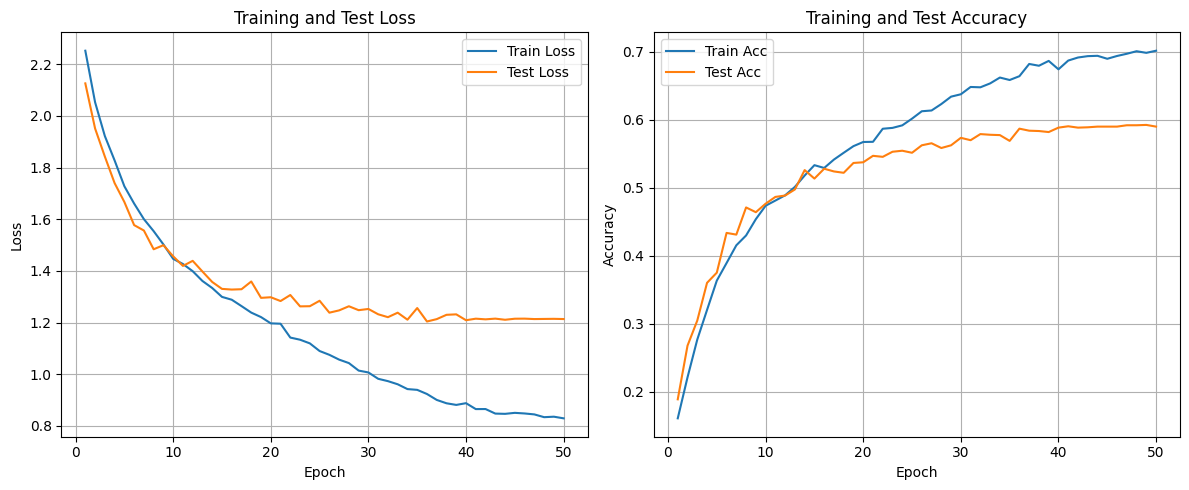

In [23]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot Losses ---
ax1.plot(metrics_df["epoch"], metrics_df["train_loss"], label="Train Loss")
ax1.plot(metrics_df["epoch"], metrics_df["test_loss"], label="Test Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Test Loss")
ax1.legend()
ax1.grid(True)

# --- Plot Accuracies ---
ax2.plot(metrics_df["epoch"], metrics_df["train_acc"], label="Train Acc")
ax2.plot(metrics_df["epoch"], metrics_df["test_acc"], label="Test Acc")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training and Test Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Saved weights loading and Num. Params check

In [23]:
best_cfg = {'EMBED_DIM': 256, 'NUM_HEADS': 8, 'DEPTH': 6, 'MLP_DIM': 512}

vit = ViT(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=CHANNELS,
    num_classes=NUM_CLASSES,
    depth=best_cfg["DEPTH"],
    num_heads=best_cfg["NUM_HEADS"],
    embed_dim=best_cfg["EMBED_DIM"],
    mlp_dim=best_cfg["MLP_DIM"],
    drop_rate=DROP_RATE,
    drop_path=DROP_RATE
)
vit = nn.DataParallel(vit)
vit = nn.DataParallel(vit)

vit.load_state_dict(torch.load("/kaggle/input/vit/pytorch/custom/1/model_weights.pth"))

num_params = sum(p.numel() for p in vit.parameters())

print("Total parameters:", num_params)

Total parameters: 3379466


### Per-Class Accuracy Analysis

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

train_indices, test_indices = train_test_split(
    range(len(dataset)),
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=labels_df["label"]
)

train_subset = labels_df.iloc[train_indices]
test_subset   = labels_df.iloc[test_indices]

train_loader, test_loader = preprocess(train_subset, test_subset, BATCH_SIZE)

# Assume you already have: model, test_loader, and labels_df["label"].unique() for class names
model.eval()  # set model to evaluation mode

all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Compute per-class accuracy
num_classes = len(np.unique(all_targets))
class_accuracies = {}

for cls in range(num_classes):
    cls_indices = np.where(all_targets == cls)[0]
    cls_correct = np.sum(all_preds[cls_indices] == all_targets[cls_indices])
    cls_total = len(cls_indices)
    class_accuracies[cls] = cls_correct / cls_total if cls_total > 0 else 0.0

# Print results with class names instead of indices
for cls, acc in class_accuracies.items():
    class_name = dataset.classes[cls]   # map index to class name
    print(f"{class_name}: Accuracy = {acc:.4f}")

Class airplane: Accuracy = 0.7277
Class automobile: Accuracy = 0.7150
Class bird: Accuracy = 0.4851
Class cat: Accuracy = 0.3503
Class deer: Accuracy = 0.5487
Class dog: Accuracy = 0.4461
Class frog: Accuracy = 0.6256
Class horse: Accuracy = 0.6256
Class ship: Accuracy = 0.7602
Class truck: Accuracy = 0.6131


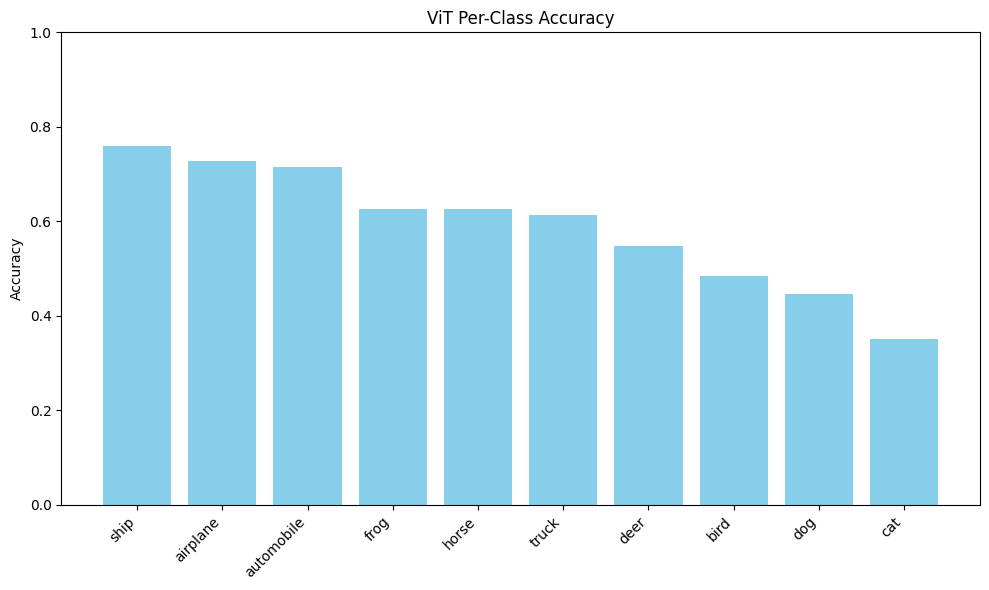

In [28]:
import matplotlib.pyplot as plt

# Sort classes by accuracy (descending)
sorted_items = sorted(class_accuracies.items(), key=lambda x: x[1], reverse=True)
sorted_classes = [dataset.classes[cls] for cls, _ in sorted_items]
sorted_accuracies = [acc for _, acc in sorted_items]

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(sorted_classes, sorted_accuracies, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("ViT Per-Class Accuracy")
plt.ylim(0, 1)  # accuracy ranges from 0 to 1
plt.tight_layout()
plt.show()